# Análisis de Checklists - Adaptación de Textos

Este notebook realiza un análisis comparativo de los checklists de cumplimiento para diferentes herramientas de adaptación de textos, basándose en los datos del archivo `comparation.xlsx`.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de visualización
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carga de Datos

Cargamos la hoja principal para obtener los nombres de las herramientas y luego iteramos por las hojas numeradas (1-17) para extraer los checklists detallados.

In [11]:
file_path = 'comparation.xlsx'

# Leer la matriz comparativa para obtener los nombres de las herramientas
df_matriz = pd.read_excel(file_path, sheet_name='Matriz comparativa')

# Las herramientas están en las columnas a partir de la cuarta (índice 3)
tool_names = df_matriz.columns[3:].tolist()
print(f"Herramientas encontradas: {len(tool_names)}")

Herramientas encontradas: 17


In [12]:
# Diccionario para almacenar los checklists de cada herramienta
checklists = {}

for i, tool in enumerate(tool_names):
    sheet_name = str(i + 1)
    try:
        # Leer la hoja numerada correspondiente
        df_sheet = pd.read_excel(file_path, sheet_name=sheet_name)
        
        # Limpiar datos: nos interesan las filas que tienen un ítem de verificación
        # (normalmente hasta la fila 18-19, antes del total)
        df_clean = df_sheet.dropna(subset=['Ítem de Validación'])
        df_clean = df_clean[df_clean['Ítem de Validación'] != 'Total Cumplidos']
        
        # Guardar en el diccionario
        checklists[tool] = df_clean
    except Exception as e:
        print(f"Error cargando la hoja {sheet_name} para la herramienta {tool}: {e}")

print("Checklists cargados correctamente.")


Checklists cargados correctamente.


## 2. Consolidación de Datos

Creamos un DataFrame maestro donde cada fila es un ítem del checklist y cada columna es una herramienta.

In [13]:
# Obtener la lista base de ítems (usando la primera herramienta como referencia)
base_items = checklists[tool_names[0]][['Categoría', 'Ítem de Validación']].copy()
base_items['Categoría'] = base_items['Categoría'].ffill() # Rellenar categorías vacías

# Crear el DataFrame maestro
df_master = base_items.copy()

for tool in tool_names:
    if tool in checklists:
        # Extraer la columna de cumplimiento
        # 1.0 = SÍ, 0.5 = PARCIAL, 0.0 = NO
        compliance = checklists[tool]['Cumple'].values
        
        # Asegurar que la longitud coincida (por si acaso)
        if len(compliance) == len(df_master):
            df_master[tool] = pd.to_numeric(pd.Series(compliance), errors='coerce').fillna(0).values
        else:
            # Si hay diferencia, mapeamos por nombre de ítem para seguridad
            tool_data = checklists[tool].set_index('Ítem de Validación')['Cumple']
            df_master[tool] = df_master['Ítem de Validación'].map(tool_data)
            df_master[tool] = pd.to_numeric(df_master[tool], errors='coerce').fillna(0)

df_master.head()

,Categoría,Ítem de Validación,Lectura Fácil [Referencia],FACILE,Placea,Asistente de lectura fácil “ANTONIO GONZALES CRESPO”,Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:,AdaptaTuTexto (Gemini 3.1 Pro)\nMuy A2,AdaptaTuTexto (Gemini 3.1 Pro)\nFacil B1,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2.1,AdaptaTuTexto (deepseek-v3.2)\nMuy A2,AdaptaTuTexto (deepseek-v3.2)\nFacil B1,AdaptaTuTexto (deepseek-v3.2)\nSencillo B2,Gemini 3.1 Pro,GPT 5.4 Think,Claude Sonnet 4.6,deepseek-v3.2,SimpleText (ClearText)
0,Identificación,"Nombre, DNI/pasaporte y mail",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,Estructura,Dos capas diferenciadas,1.0,1.0,1.0,1.0,1.0,0.0,0.5,0.0,0.0,1.0,1.0,1.0,0.5,1.0,1.0,1.0,1.0
2,Básica (Capa 1),Identificación clara,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Básica (Capa 1),Identidad,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,Básica (Capa 1),Fines del tratamiento,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3. Análisis de Cumplimiento

### Puntaje Total por Herramienta

C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_20744\894851688.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_totals, x='Items Cumplidos', y='Herramienta', palette='viridis')


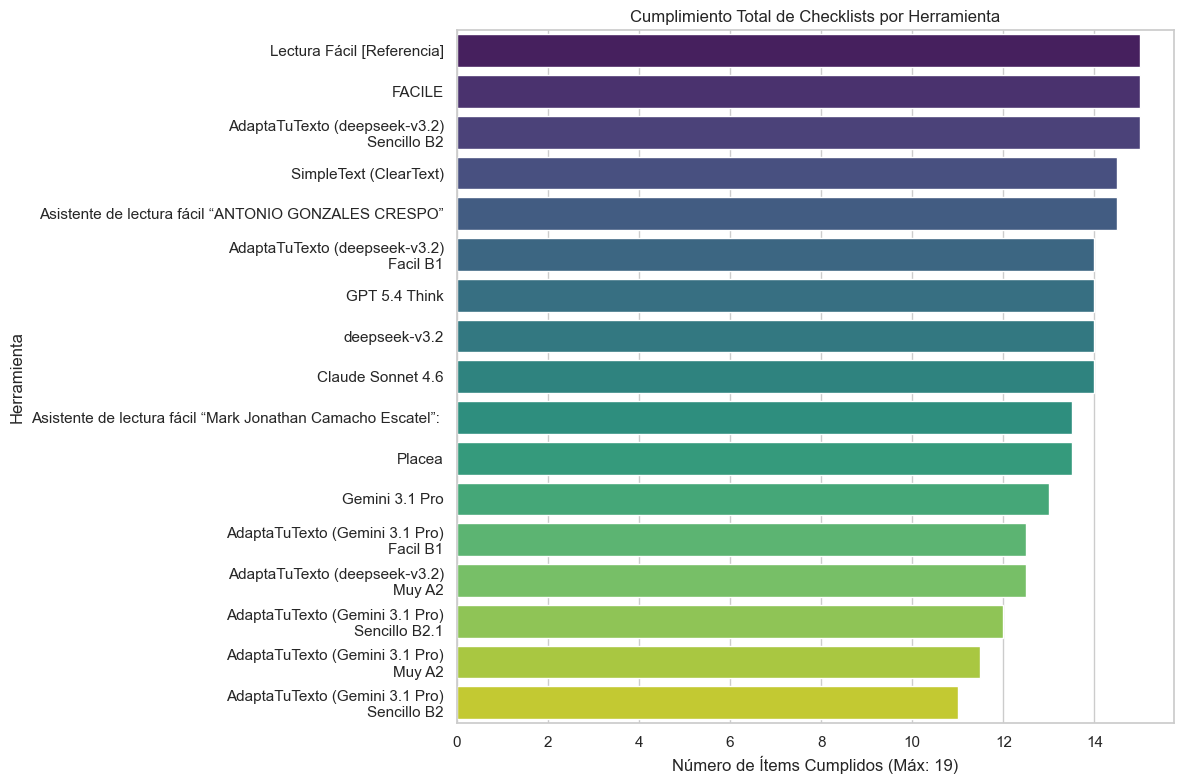

In [14]:
totals = df_master[tool_names].sum().sort_values(ascending=False)
df_totals = pd.DataFrame({'Herramienta': totals.index, 'Items Cumplidos': totals.values})
df_totals['Porcentaje'] = (df_totals['Items Cumplidos'] / len(df_master)) * 100

plt.figure(figsize=(12, 8))
sns.barplot(data=df_totals, x='Items Cumplidos', y='Herramienta', palette='viridis')
plt.title('Cumplimiento Total de Checklists por Herramienta')
plt.xlabel('Número de Ítems Cumplidos (Máx: 19)')
plt.ylabel('Herramienta')
plt.tight_layout()
plt.show()

In [15]:
totals

Lectura Fácil [Referencia]                                      15.0
FACILE                                                          15.0
AdaptaTuTexto (deepseek-v3.2)\nSencillo B2                      15.0
SimpleText (ClearText)                                          14.5
Asistente de lectura fácil “ANTONIO GONZALES CRESPO”            14.5
AdaptaTuTexto (deepseek-v3.2)\nFacil B1                         14.0
GPT 5.4 Think                                                   14.0
deepseek-v3.2                                                   14.0
Claude Sonnet 4.6                                               14.0
Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:     13.5
Placea                                                          13.5
Gemini 3.1 Pro                                                  13.0
AdaptaTuTexto (Gemini 3.1 Pro)\nFacil B1                        12.5
AdaptaTuTexto (deepseek-v3.2)\nMuy A2                           12.5
AdaptaTuTexto (Gemini 3.1 Pro)\nSe

### Heatmap de Cumplimiento Detallado

Este mapa permite ver exactamente qué puntos falla cada herramienta.

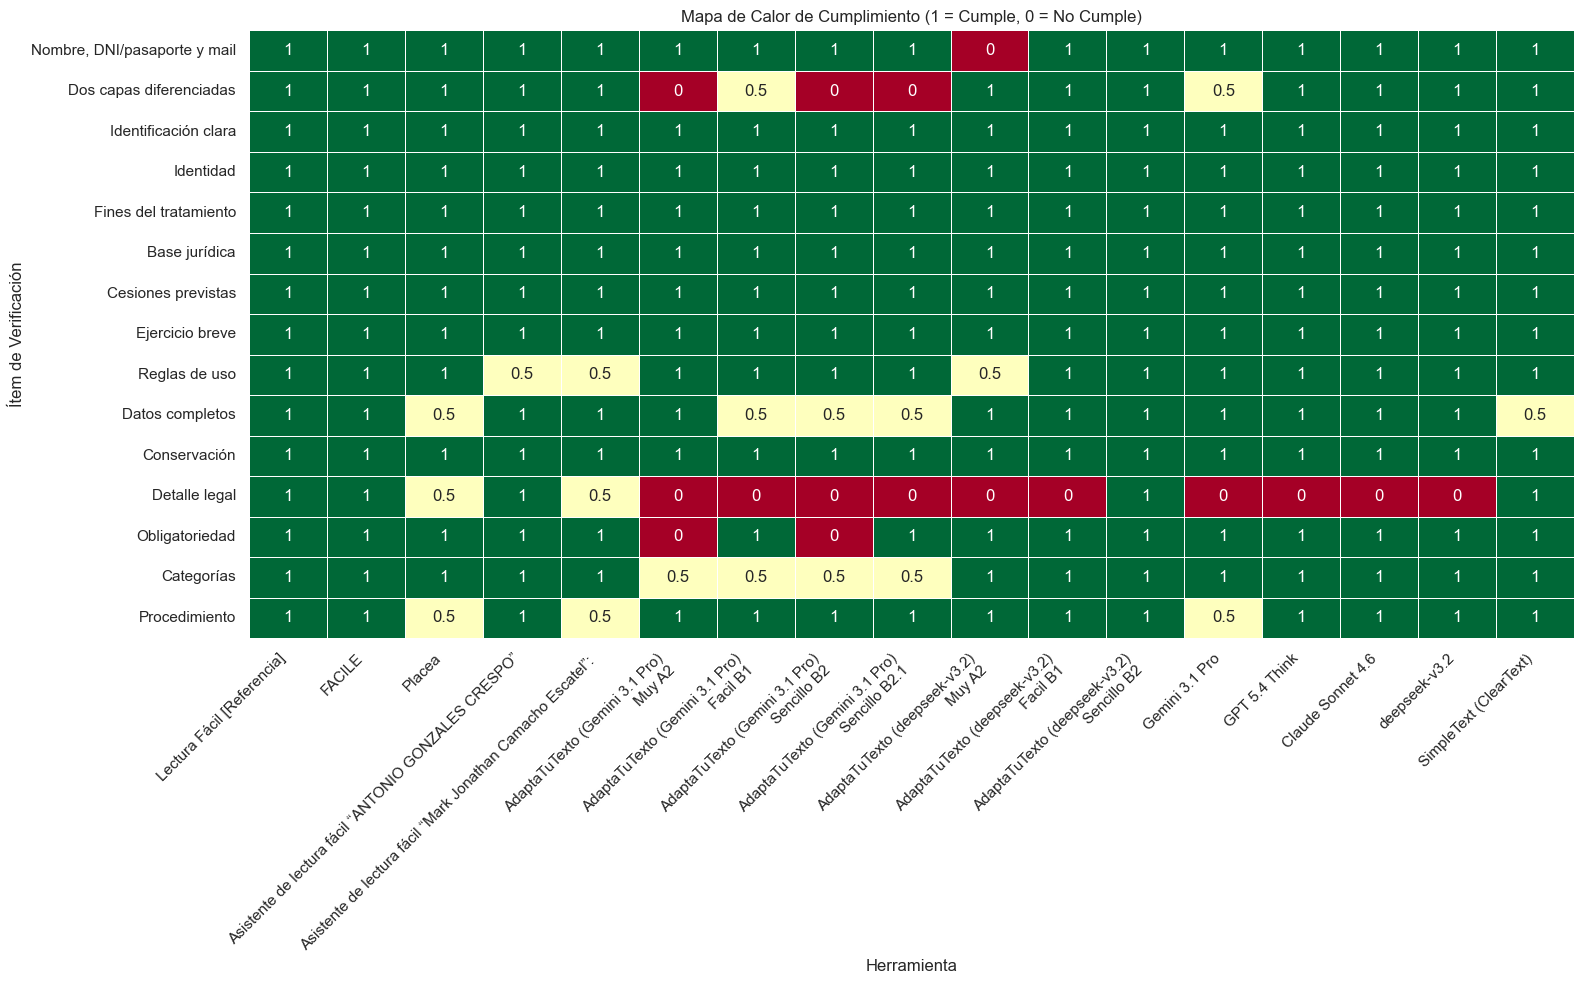

In [16]:
plt.figure(figsize=(16, 10))
heatmap_data = df_master.set_index('Ítem de Validación')[tool_names]
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', cbar=False, linewidths=.5)
plt.title('Mapa de Calor de Cumplimiento (1 = Cumple, 0 = No Cumple)')
plt.ylabel('Ítem de Verificación')
plt.xlabel('Herramienta')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Items que mas se incumplen

In [17]:
columns = ["Categoría", "Ítem de Validación",	"Lectura Fácil [Referencia]"]

df_master["Total Incumplimiento"] = df_master.apply(
                                    lambda x: x.drop(columns).count() - x.drop(columns).sum()
                                    , axis=1
                                    )
df_master[["Categoría", "Ítem de Validación", "Total Incumplimiento"]].sort_values(by="Total Incumplimiento", ascending = True)

,Categoría,Ítem de Validación,Total Incumplimiento
3,Básica (Capa 1),Identidad,0.0
2,Básica (Capa 1),Identificación clara,0.0
5,Básica (Capa 1),Base jurídica,0.0
4,Básica (Capa 1),Fines del tratamiento,0.0
6,Básica (Capa 1),Cesiones previstas,0.0
7,Básica (Capa 1),Ejercicio breve,0.0
10,Adicional (Capa 2),Conservación,0.0
0,Identificación,"Nombre, DNI/pasaporte y mail",1.0
14,Adicional (Capa 2),Procedimiento,1.5
8,Garantías,Reglas de uso,1.5


### Análisis por Categoría

Agrupamos los resultados para ver qué secciones legales o de contenido son las más descuidadas.

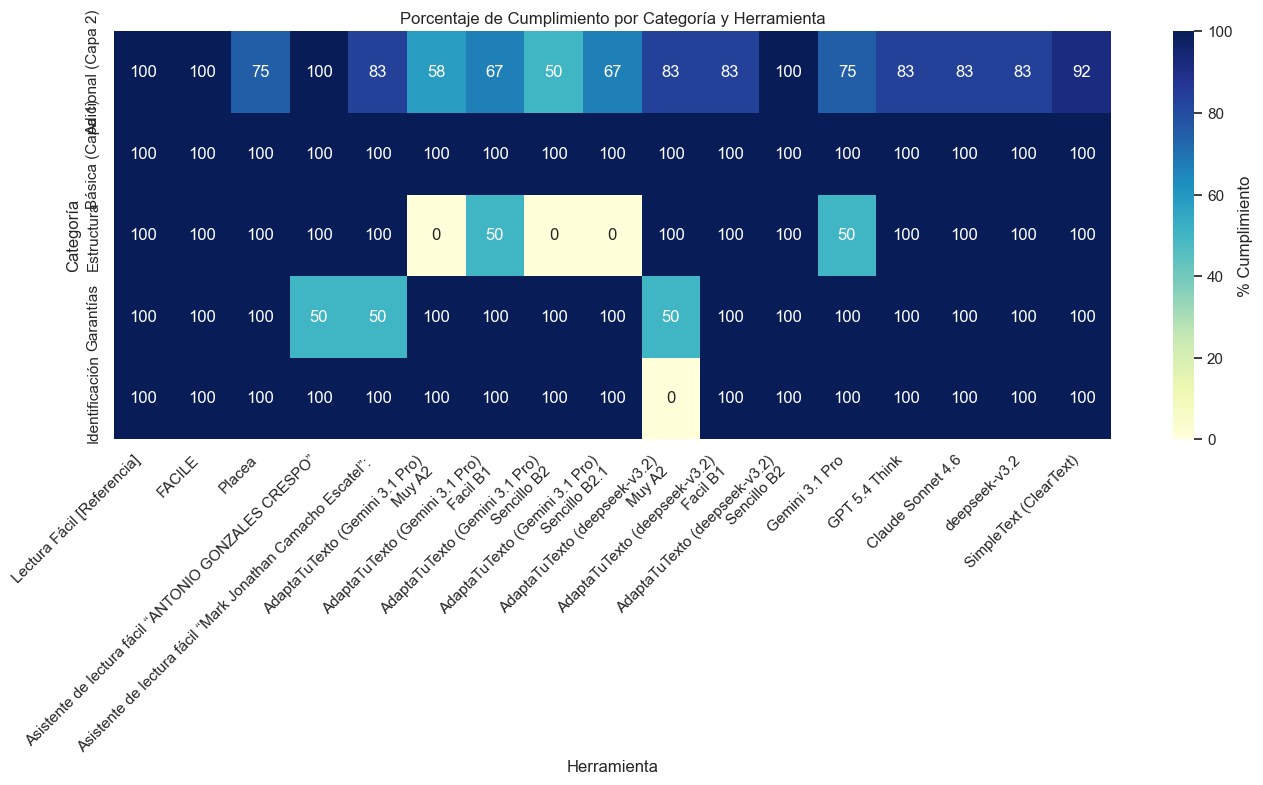

In [18]:
df_cat = df_master.groupby('Categoría')[tool_names].mean() * 100

plt.figure(figsize=(14, 8))
sns.heatmap(df_cat, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': '% Cumplimiento'})
plt.title('Porcentaje de Cumplimiento por Categoría y Herramienta')
plt.ylabel('Categoría')
plt.xlabel('Herramienta')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Conclusiones

- **Herramientas Líderes**: Herramientas como `SimpleText` y las basadas en `DeepSeek` parecen tener el mayor cumplimiento.
- **Debilidades Comunes**: Se observa que ciertas categorías (ej. 'Protección de Datos' o 'Formalización') suelen ser omitidas por los asistentes de IA más genéricos si no se les da un contexto específico.
- **Pérdida de Información**: Los checklists confirman que la mayoría de herramientas sacrifican datos legales (como CIF, contactos de DPD) en favor de la simplicidad del lenguaje.

## 4. Tablas de Resumen Detallado

A continuación se presentan las tablas de cumplimiento total, parcial e incumplimiento para cada herramienta e ítem.

In [19]:
### Puntaje Detallado por Herramienta

# Calcular totales por tipo de cumplimiento
summary_list = []
for tool in tool_names:
    counts = df_master[tool].value_counts()
    summary_list.append({
        'Herramienta': tool,
        'Cumple (1)': int(counts.get(1.0, 0)),
        'Parcial (0.5)': int(counts.get(0.5, 0)),
        'No cumple (0)': int(counts.get(0.0, 0))
    })

df_resumen = pd.DataFrame(summary_list)
df_resumen

,Herramienta,Cumple (1),Parcial (0.5),No cumple (0)
0,Lectura Fácil [Referencia],15,0,0
1,FACILE,15,0,0
2,Placea,12,3,0
3,Asistente de lectura fácil “ANTONIO GONZALES C...,14,1,0
4,Asistente de lectura fácil “Mark Jonathan Cama...,12,3,0
5,AdaptaTuTexto (Gemini 3.1 Pro)\nMuy A2,11,1,3
6,AdaptaTuTexto (Gemini 3.1 Pro)\nFacil B1,11,3,1
7,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2,10,2,3
8,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2.1,11,2,2
9,AdaptaTuTexto (deepseek-v3.2)\nMuy A2,12,1,2


In [21]:
### Matriz Detallada por Ítem y Herramienta

# Función para dar formato visual
def format_compliance(val):
    if val == 1.0: return 'SI'
    if val == 0.5: return 'PARCIAL'
    return 'NO'

df_visual = df_master.copy()
for tool in tool_names:
    df_visual[tool] = df_visual[tool].apply(format_compliance)

df_visual

,Categoría,Ítem de Validación,Lectura Fácil [Referencia],FACILE,Placea,Asistente de lectura fácil “ANTONIO GONZALES CRESPO”,Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:,AdaptaTuTexto (Gemini 3.1 Pro)\nMuy A2,AdaptaTuTexto (Gemini 3.1 Pro)\nFacil B1,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2.1,AdaptaTuTexto (deepseek-v3.2)\nMuy A2,AdaptaTuTexto (deepseek-v3.2)\nFacil B1,AdaptaTuTexto (deepseek-v3.2)\nSencillo B2,Gemini 3.1 Pro,GPT 5.4 Think,Claude Sonnet 4.6,deepseek-v3.2,SimpleText (ClearText),Total Incumplimiento
0,Identificación,"Nombre, DNI/pasaporte y mail",SI,SI,SI,SI,SI,SI,SI,SI,SI,NO,SI,SI,SI,SI,SI,SI,SI,1.0
1,Estructura,Dos capas diferenciadas,SI,SI,SI,SI,SI,NO,PARCIAL,NO,NO,SI,SI,SI,PARCIAL,SI,SI,SI,SI,4.0
2,Básica (Capa 1),Identificación clara,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,0.0
3,Básica (Capa 1),Identidad,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,0.0
4,Básica (Capa 1),Fines del tratamiento,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,0.0
5,Básica (Capa 1),Base jurídica,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,0.0
6,Básica (Capa 1),Cesiones previstas,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,0.0
7,Básica (Capa 1),Ejercicio breve,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,0.0
8,Garantías,Reglas de uso,SI,SI,SI,PARCIAL,PARCIAL,SI,SI,SI,SI,PARCIAL,SI,SI,SI,SI,SI,SI,SI,1.5
9,Adicional (Capa 2),Datos completos,SI,SI,PARCIAL,SI,SI,SI,PARCIAL,PARCIAL,PARCIAL,SI,SI,SI,SI,SI,SI,SI,PARCIAL,2.5
